In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 配置参数
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
SEED = 42

# 🔥 关键：改成你这里的真实路径！
BASE_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'

# 创建保存图片的文件夹
os.makedirs('/kaggle/working/figures', exist_ok=True)

In [4]:
def count_images(path):
    normal = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    return normal, pneumonia

train_nor, train_pne = count_images(os.path.join(BASE_DIR, 'train'))
test_nor, test_pne = count_images(os.path.join(BASE_DIR, 'test'))
val_nor, val_pne = count_images(os.path.join(BASE_DIR, 'val'))

print("===== 数据集样本统计 =====")
print(f"训练集：正常{train_nor}张，肺炎{train_pne}张")
print(f"测试集：正常{test_nor}张，肺炎{test_pne}张")
print(f"验证集：正常{val_nor}张，肺炎{val_pne}张")

===== 数据集样本统计 =====
训练集：正常1342张，肺炎3876张
测试集：正常234张，肺炎390张
验证集：正常9张，肺炎9张


In [6]:
# 训练集数据增强 + 划分 8:2 验证集
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2  # 20%做验证集
)

# 测试集只归一化
test_datagen = ImageDataGenerator(rescale=1./255)

# 加载训练集（80%）
train_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

# 加载验证集（20%）
val_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

# 加载官方测试集
test_gen = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
def build_cnn_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_model()
model.summary()  # 打印模型结构

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-29 13:45:45.321668: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,609 (36.49 MB)

 Trainable params: 9,564,161 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# 早停策略：防止过拟合
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

# 开始训练
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.8360 - loss: 0.6574 - val_accuracy: 0.7430 - val_loss: 3.8716
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9126 - loss: 0.2139 - val_accuracy: 0.7430 - val_loss: 6.4020
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9172 - loss: 0.2008 - val_accuracy: 0.7430 - val_loss: 4.6228
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9343 - loss: 0.1675 - val_accuracy: 0.7565 - val_loss: 1.3098
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9284 - loss: 0.1801 - val_accuracy: 0.9358 - val_loss: 0.1475
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9400 - loss: 0.1538 - val_accuracy: 0.9348 - val_loss: 0.1575
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9382 - loss: 0.1479 - val_accuracy: 0.9425 - val_loss: 0.1463
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9511 - loss: 0.1281 - val_accu

/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2417241.py:21: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.

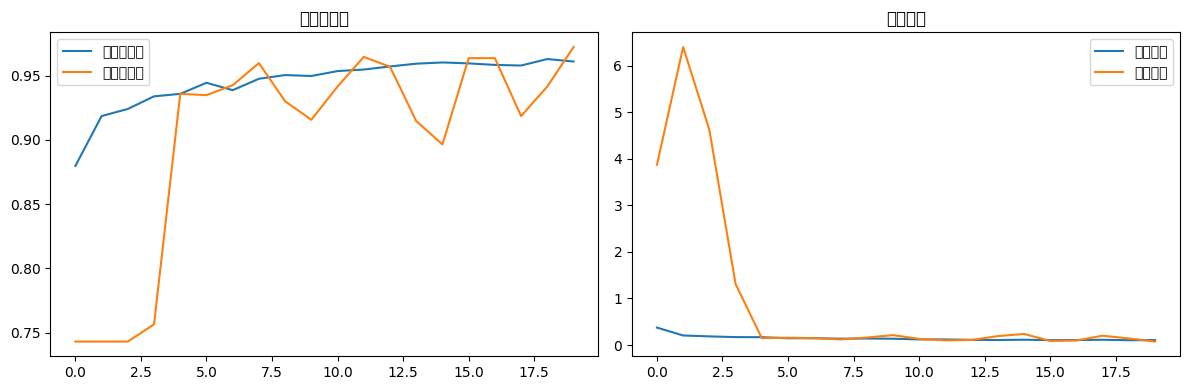

In [9]:
def plot_loss_acc(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='训练准确率')
    plt.plot(epochs, val_acc, label='验证准确率')
    plt.legend()
    plt.title('准确率曲线')

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='训练损失')
    plt.plot(epochs, val_loss, label='验证损失')
    plt.legend()
    plt.title('损失曲线')

    plt.tight_layout()
    plt.savefig('/kaggle/working/figures/train_curve.png')  # 保存图片
    plt.show()

plot_loss_acc(history)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 627ms/step
========== 测试集评估指标 ==========
              precision    recall  f1-score   support

          正常       0.96      0.56      0.70       234
          肺炎       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.77      0.79       624
weighted avg       0.85      0.83      0.81       624



/tmp/ipykernel_57/4284330012.py:17: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
/tmp/ipykernel_57/4284330012.py:17: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
/tmp/ipykernel_57/4284330012.py:17: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
/tmp/ipykernel_57/4284330012.py:17: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
/tmp/ipykernel_57/4284330012.py:17: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
/tmp/ipyke

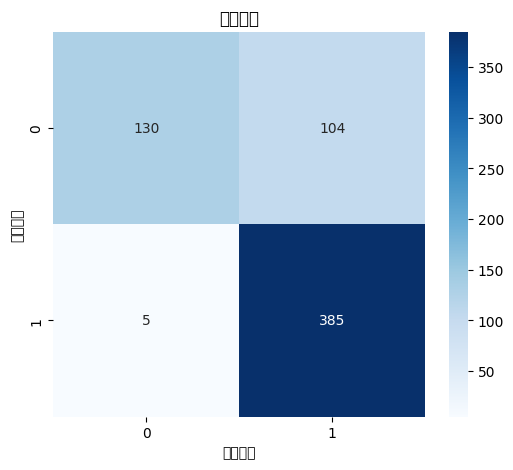

In [10]:
# 预测测试集
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# 输出分类报告（Accuracy/Precision/Recall/F1）
print("========== 测试集评估指标 ==========")
print(classification_report(y_true, y_pred, target_names=['正常','肺炎']))

# 绘制混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('混淆矩阵')
plt.savefig('/kaggle/working/figures/confusion_matrix.png')  # 保存图片
plt.show()